<div align="center">

<img src="https://s3.amazonaws.com/files.pucp.edu.pe/pucp-general/img-header/logo-pucp-new.svg" alt="Pontificia Universidad Católica del Perú">

<br><br>

## Pontificia Universidad Católica del Perú  

### Deep Learning con Python  

<br>

## Clase 2 — Laboratorio 1  

### Obtención y Pre-procesamiento del Dataset  

### 🐶 Dogs vs Non-Dogs  

</div>

---

📥 Descarga de Imágenes — Clase Dogs

En esta sección se realiza la descarga automática de imágenes correspondientes a la clase perros, las cuales formarán parte del dataset del proyecto Dogs vs Non-Dogs.

Para mejorar la diversidad de las muestras y evitar sesgos en el modelo, se utilizan múltiples consultas de búsqueda que permiten obtener imágenes de perros en diferentes poses, contextos y fondos.

Las imágenes descargadas serán almacenadas en el directorio dataset_v3, donde posteriormente se realizará el proceso de limpieza, validación y pre-procesamiento.

Objetivo de esta celda:

- Obtener imágenes reales de perros desde internet

- Incrementar la variabilidad del dataset mediante diferentes queries

- Construir el conjunto inicial de datos para la clase positiva

In [1]:
# IMPORTACION DE LIBRERIAS

import os
import shutil
from bing_image_downloader import downloader
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
downloader.download("single real dog full body photo", limit=50, output_dir='dataset_v1')
downloader.download("one real dog standing alone", limit=50, output_dir='dataset_v1')
downloader.download("real dog isolated on background", limit=50, output_dir='dataset_v1')

[%] Downloading Images to /Users/larenwell/Documents/personal/projects/ai-dl-tensorflow-specialization-fabricum-pucp/dataset_v1/dog/single real dog full body photo


[!!]Indexing page: 1

[%] Indexed 35 Images on Page 1.


[%] Downloading Image #1 from https://img.freepik.com/premium-photo/dog-full-body-shot-single_933496-31682.jpg
[%] File Downloaded !

[%] Downloading Image #2 from https://img.freepik.com/premium-photo/dog-full-body-shot-single_933496-31686.jpg
[%] File Downloaded !

[%] Downloading Image #3 from https://image.shutterstock.com/z/stock-photo-closeup-of-brown-and-white-terrier-dog-with-blue-eyes-and-happy-friendly-expression-1231021225.jpg
[%] File Downloaded !

[%] Downloading Image #4 from https://img.freepik.com/premium-photo/dog-full-body-shot-single_933496-31688.jpg
[%] File Downloaded !

[%] Downloading Image #5 from https://www.shutterstock.com/shutterstock/photos/2349745353/display_1500/stock-photo-happy-husky-dog-sitting-smiling-isolated-cutout-on-white-backgr

📥 Descarga de Imágenes — Clase Non-Dogs

En esta sección se realiza la descarga automática de imágenes que no corresponden a perros, las cuales conformarán la clase negativa del dataset.

Se incluyen diferentes categorías como gatos, aves y flores con el objetivo de proporcionar mayor diversidad y ayudar al modelo a aprender a distinguir correctamente entre imágenes que contienen perros y aquellas que no.

Las imágenes serán almacenadas en el directorio dataset_v3, donde posteriormente serán procesadas y validadas.

Objetivo de esta celda:

- Obtener imágenes de distintas categorías que no sean perros

- Construir la clase negativa del dataset

- Incrementar la capacidad del modelo para diferenciar entre clases

In [3]:
downloader.download("single real cat full body photo", limit=50, output_dir='dataset_v1')
downloader.download("one real bird standing alone", limit=50, output_dir='dataset_v1')
downloader.download("real flower isolated on background", limit=50, output_dir='dataset_v1')

[%] Downloading Images to /Users/larenwell/Documents/personal/projects/ai-dl-tensorflow-specialization-fabricum-pucp/dataset_v1/single real cat full body photo


[!!]Indexing page: 1

[%] Indexed 35 Images on Page 1.


[%] Downloading Image #1 from https://img.freepik.com/premium-photo/cat-full-body-shot-single_933496-31620.jpg?w=2000
[%] File Downloaded !

[%] Downloading Image #2 from https://img.freepik.com/premium-photo/cat-full-body-shot-single_933496-31617.jpg?w=740
[%] File Downloaded !

[%] Downloading Image #3 from https://images.pexels.com/photos/7726106/pexels-photo-7726106.jpeg?cs=srgb&amp;dl=pexels-arina-krasnikova-7726106.jpg&amp;fm=jpg
[%] File Downloaded !

[%] Downloading Image #4 from https://img.freepik.com/premium-photo/clear-background-cat-full-body-view_1101231-3313.jpg?w=2000
[%] File Downloaded !

[%] Downloading Image #5 from https://img.freepik.com/premium-photo/full-body-portrait-single-spotted-bengal-cat-sit-looking-camera-isolated-black-background_155390-13

🗂️ Organización del Dataset

Luego de la descarga de imágenes desde distintas consultas, es necesario estructurar el dataset en una organización clara por clases para facilitar su uso en el entrenamiento del modelo.

En esta sección se agrupan todas las imágenes descargadas en dos carpetas principales:

🐶 dog → contiene imágenes correspondientes a la clase positiva

🚫🐶 non_dog → contiene imágenes de otras categorías

Además, las imágenes son renombradas de forma secuencial para mantener consistencia, evitar duplicados y facilitar su manipulación durante el pipeline de procesamiento.

Objetivo de esta celda:

- Consolidar imágenes provenientes de múltiples carpetas

- Separar correctamente las clases del dataset

- Renombrar archivos de forma ordenada

- Preparar la estructura final para el entrenamiento

In [5]:
# CARPETA BASE
base_path = 'dataset_v1'

# CREAR LAS CARPETAS PARA DOG Y NON_DOG
dog_folder=os.path.join(base_path, 'dog')
non_dog_folder=os.path.join(base_path, 'non_dog')
os.makedirs(dog_folder, exist_ok=True)  # el exist_ok=True es para que no salga un error si la carpeta ya existe
os.makedirs(non_dog_folder, exist_ok=True)

# FUENTES DE IMAGENES DOG
dog_sources = ["one real dog standing alone", 
"real dog isolated on background", 
"single real dog full body photo"]

# FUENTES DE IMAGENES NON_DOG
non_dog_sources = ["single real cat full body photo", 
"one real bird standing alone", 
"real flower isolated on background"]

# FUNCION PARA MOVER LAS IMAGENES
def move_images(source_folders, destination_folder, prefix):
    counter = 0
    for folder in source_folders:
        folder_path = os.path.join(base_path, folder)
        for filename in os.listdir(folder_path):
            src = os.path.join(folder_path, filename)
            if os.path.isfile(src):
                new_name = f"{prefix}_{counter}.jpg"
                dst = os.path.join(destination_folder, new_name)
                shutil.move(src, dst)
                counter += 1

# EJECUTAR EL MOVIMIENTO DE LAS IMAGENES Y ALMACENAR EN LAS CARPETAS ADECUADAS
move_images(dog_sources, dog_folder, 'dog')
move_images(non_dog_sources, non_dog_folder, 'non_dog')


🖼️ Redimensionamiento de Imágenes

Para garantizar consistencia en los datos de entrada y optimizar el proceso de entrenamiento del modelo, es necesario estandarizar el tamaño de todas las imágenes del dataset.

En esta sección se redimensionan las imágenes de ambas clases (dog y non_dog) a un tamaño uniforme de 128x128 píxeles, lo que permite reducir el costo computacional y asegurar que el modelo reciba entradas con dimensiones homogéneas.

Las imágenes procesadas se almacenan en una nueva carpeta (dataset_v1_resized), preservando la estructura por clases.

Objetivo de esta celda:

- Estandarizar el tamaño de todas las imágenes

- Reducir la complejidad computacional

- Preparar los datos para el entrenamiento del modelo

- Mantener la estructura organizada por clases

In [6]:
# CARPETAS PARA ORDENAR IMAGENES
input_base = "dataset_v1"
output_base = "dataset_v1_resized"
classes = ["dog", "non_dog"]

# CREAR UNA CARPETA PARA CADA CLASE
for cls in classes:
    os.makedirs(os.path.join(output_base, cls), exist_ok=True)

# TAMAÑO DE LAS IMAGENES
size = (128,128) 
# Me permite modificar el tamaño de las imágenes para que entrenen mejor en pixele
# El primer numero es el ancho y el segundo es el alto.

# ITERATIVA PARA REDIMENSIONAR LAS IMAGENES
for cls in classes:
    input_folder = os.path.join(input_base, cls)
    output_folder = os.path.join(output_base, cls)
    for filename in os.listdir(input_folder):
        if filename.lower().endswith((".jpg", ".jpeg", ".png")):
            try:
                img_path = os.path.join(input_folder, filename)
                img = Image.open(img_path).convert("RGB")
                img_resized = img.resize(size, Image.LANCZOS)
                save_path = os.path.join(output_folder, filename)
                img_resized.save(save_path, "JPEG")
            except Exception as e:
                print(f"Error con {filename}: {e}")

🔍 Verificación de Dimensiones

En esta sección se realiza una verificación rápida del tamaño de las imágenes procesadas para confirmar que el proceso de redimensionamiento se ejecutó correctamente.

Se carga una imagen de muestra del dataset y se inspeccionan sus dimensiones, asegurando que coincidan con el tamaño definido en la etapa de preprocesamiento.

In [7]:
# LEER UNA IMAGEN CON IMAGE.OPEN Y VALIDAR SUS DIMENSIONES
img=Image.open("dataset_v1_resized/dog/dog_0.jpg")

print(img.size)


(128, 128)


🧠 Construcción del Dataset Estructurado

En esta sección se recorre la estructura del dataset procesado para construir dos listas fundamentales: una que contiene las rutas de todas las imágenes y otra con sus respectivas etiquetas.

Se asigna la etiqueta 1 a las imágenes de la clase dog y 0 a las imágenes de la clase non_dog, permitiendo representar el dataset en un formato supervisado que podrá ser utilizado directamente en el proceso de entrenamiento del modelo.

Este paso transforma el dataset desde una organización basada en carpetas hacia una estructura de datos lista para el pipeline de Machine Learning.

In [8]:
# LEA LOS DATASETS (UBICACIONES Y ETIQUETAS), TANTO LAS IMAGENES COMO SUS ETIQUETAS PARA PODER PREVISUALIZAR EJEMPLOS EN LA SIGUIENTE CELDA
# ALMACENAR LOS DATOS EN LOS ARREGLOS IMAGE_PATHS Y LABELS

base_path = "dataset_v1_resized"
classes = ["dog", "non_dog"]
image_paths = []
labels = []


for cls in classes:
    folder_path = os.path.join(base_path, cls)
    for filename in os.listdir(folder_path):
        if filename.lower().endswith((".jpg", ".jpeg", ".png")):
            image_path = os.path.join(folder_path, filename)
            image_paths.append(image_path)
            labels.append(1 if cls == "dog" else 0)


🖼️ Inspección Visual del Dataset

En esta sección se visualiza una imagen del dataset junto con su etiqueta correspondiente para verificar que las imágenes se cargan correctamente y que la asignación de clases es consistente.

Esta validación permite confirmar la correcta correspondencia entre los datos y sus etiquetas antes de continuar con el proceso de entrenamiento.

In [12]:
# USE LA VARIABLE INDEX PARA INSPECCIONAR ALGUNOS EJEMPLOS DEL DATASET
classes = ["non-dog", "dog"]
index = 175
img=Image.open(image_paths[index])

0


Text(0.5, 1.0, 'Label: 0->non-dog')

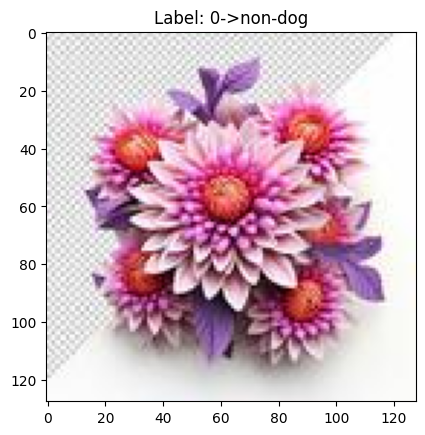

In [17]:
plt.imshow(img)
plt.title(f"Label: {labels[index]}->{classes[labels[index]]}")

In [22]:
image_paths

['dataset_v1_resized/dog/dog_13.jpg',
 'dataset_v1_resized/dog/dog_147.jpg',
 'dataset_v1_resized/dog/dog_146.jpg',
 'dataset_v1_resized/dog/dog_12.jpg',
 'dataset_v1_resized/dog/dog_38.jpg',
 'dataset_v1_resized/dog/dog_10.jpg',
 'dataset_v1_resized/dog/dog_144.jpg',
 'dataset_v1_resized/dog/dog_145.jpg',
 'dataset_v1_resized/dog/dog_11.jpg',
 'dataset_v1_resized/dog/dog_39.jpg',
 'dataset_v1_resized/dog/dog_9.jpg',
 'dataset_v1_resized/dog/dog_15.jpg',
 'dataset_v1_resized/dog/dog_29.jpg',
 'dataset_v1_resized/dog/dog_141.jpg',
 'dataset_v1_resized/dog/dog_140.jpg',
 'dataset_v1_resized/dog/dog_28.jpg',
 'dataset_v1_resized/dog/dog_14.jpg',
 'dataset_v1_resized/dog/dog_8.jpg',
 'dataset_v1_resized/dog/dog_16.jpg',
 'dataset_v1_resized/dog/dog_142.jpg',
 'dataset_v1_resized/dog/dog_143.jpg',
 'dataset_v1_resized/dog/dog_17.jpg',
 'dataset_v1_resized/dog/dog_58.jpg',
 'dataset_v1_resized/dog/dog_70.jpg',
 'dataset_v1_resized/dog/dog_64.jpg',
 'dataset_v1_resized/dog/dog_118.jpg',
 'dat